In [72]:
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv("../data/owid-covid-data.csv")

In [74]:
#import os
#os.listdir()

# 1. Understand the data

In [76]:
df.head

<bound method NDFrame.head of        iso_code continent     location        date  total_cases  new_cases  \
0           AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1           AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2           AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3           AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4           AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   
...         ...       ...          ...         ...          ...        ...   
429430      ZWE    Africa     Zimbabwe  2024-07-31     266386.0        0.0   
429431      ZWE    Africa     Zimbabwe  2024-08-01     266386.0        0.0   
429432      ZWE    Africa     Zimbabwe  2024-08-02     266386.0        0.0   
429433      ZWE    Africa     Zimbabwe  2024-08-03     266386.0        0.0   
429434      ZWE    Africa     Zimbabwe  2024-08-04     266386.0        0.0   

        new_cases_smoothed  total

In [77]:
df.shape

(429435, 67)

In [78]:
df.columns.tolist() #convert the columns to a list, easier to read

['iso_code',
 'continent',
 'location',
 'date',
 'total_cases',
 'new_cases',
 'new_cases_smoothed',
 'total_deaths',
 'new_deaths',
 'new_deaths_smoothed',
 'total_cases_per_million',
 'new_cases_per_million',
 'new_cases_smoothed_per_million',
 'total_deaths_per_million',
 'new_deaths_per_million',
 'new_deaths_smoothed_per_million',
 'reproduction_rate',
 'icu_patients',
 'icu_patients_per_million',
 'hosp_patients',
 'hosp_patients_per_million',
 'weekly_icu_admissions',
 'weekly_icu_admissions_per_million',
 'weekly_hosp_admissions',
 'weekly_hosp_admissions_per_million',
 'total_tests',
 'new_tests',
 'total_tests_per_thousand',
 'new_tests_per_thousand',
 'new_tests_smoothed',
 'new_tests_smoothed_per_thousand',
 'positive_rate',
 'tests_per_case',
 'tests_units',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'total_boosters',
 'new_vaccinations',
 'new_vaccinations_smoothed',
 'total_vaccinations_per_hundred',
 'people_vaccinated_per_hundred',
 'peo

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

# 2. Select and clean the data

In [81]:
df[["location", "date", "new_cases", "new_deaths", "people_vaccinated", "total_vaccinations"]].head()

,location,date,new_cases,new_deaths,people_vaccinated,total_vaccinations
0,Afghanistan,2020-01-05,0.0,0.0,NaN,NaN
1,Afghanistan,2020-01-06,0.0,0.0,NaN,NaN
2,Afghanistan,2020-01-07,0.0,0.0,NaN,NaN
3,Afghanistan,2020-01-08,0.0,0.0,NaN,NaN
4,Afghanistan,2020-01-09,0.0,0.0,NaN,NaN


In [82]:
countries = ["United States","China","Japan","Germany"]
df_selected = df[df["location"].isin(countries)].copy()
df_selected["location"].unique()
df_selected.shape

(6696, 67)

In [83]:
# change the data format from string to datatime
df_selected["date"] = pd.to_datetime(df_selected["date"])
df_selected["date"].min(), df_selected["date"].max()

(Timestamp('2020-01-05 00:00:00'), Timestamp('2024-08-04 00:00:00'))

In [84]:
cols = [
    "location",
    "date",
    "population",
    "new_cases",
    "new_deaths",
    "total_cases",
    "total_deaths",
    "people_vaccinated",
    "total_vaccinations"
]

df_clean = df_selected[cols].copy()

In [85]:
df_clean.head()

,location,date,population,new_cases,new_deaths,total_cases,total_deaths,people_vaccinated,total_vaccinations
73670,China,2020-01-05,1425887360,1.0,0.0,1.0,0.0,NaN,NaN
73671,China,2020-01-06,1425887360,0.0,0.0,1.0,0.0,NaN,NaN
73672,China,2020-01-07,1425887360,0.0,0.0,1.0,0.0,NaN,NaN
73673,China,2020-01-08,1425887360,0.0,0.0,1.0,0.0,NaN,NaN
73674,China,2020-01-09,1425887360,0.0,0.0,1.0,0.0,NaN,NaN


In [86]:
df_clean.isna().sum()

location                 0
date                     0
population               0
new_cases              834
new_deaths             393
total_cases              0
total_deaths             0
people_vaccinated     4147
total_vaccinations    3514
dtype: int64

In [87]:
df_clean.isna().mean().sort_values(ascending=False) #.isna().mean() means to find the ratio of true (1+0+1)/3 = 66.7%

people_vaccinated     0.619325
total_vaccinations    0.524791
new_cases             0.124552
new_deaths            0.058692
location              0.000000
date                  0.000000
population            0.000000
total_cases           0.000000
total_deaths          0.000000
dtype: float64

In [88]:
df_clean["new_cases"] = df_clean["new_cases"].fillna(0) # fill 0 for nan
df_clean["new_deaths"] = df_clean["new_deaths"].fillna(0)

In [89]:
df_clean["people_vaccinated"] = df_clean.groupby("location")["people_vaccinated"].ffill() #ffill, forward fill, [100 nan nan 180] -> [100 100 100 180]
df_clean["total_vaccinations"] = df_clean.groupby("location")["total_vaccinations"].ffill()

In [90]:
df_clean.isna().sum()

location                 0
date                     0
population               0
new_cases                0
new_deaths               0
total_cases              0
total_deaths             0
people_vaccinated     1631
total_vaccinations    1454
dtype: int64

# 3. Data transformation and statistical analysis

In [92]:
df_clean["new_cases_per_million"] = df_clean["new_cases"]/df_clean["population"]*1_000_000 #to fairly compare between different countries
df_clean["new_deaths_per_million"] = df_clean["new_deaths"]/df_clean["population"]*1_000_000
df_clean["total_deaths_per_million"] = df_clean["total_deaths"]/df_clean["population"]*1_000_000

In [93]:
df_clean["new_cases_7day_avg"] = (
    df_clean
    .groupby("location")["new_cases_per_million"]
    .transform(lambda x: x.rolling(7,min_periods = 1).mean())
)

df_clean["new_deaths_7day_avg"] = (
    df_clean
    .groupby("location")["new_deaths_per_million"]
    .transform(lambda x: x.rolling(7,min_periods = 1).mean())
)

In [94]:
# max new deaths per day of each country
df_clean.groupby("location")["new_deaths_per_million"].max().sort_values(ascending = False)

location
Japan            88.590962
Germany          77.486055
United States    68.911318
China            33.443736
Name: new_deaths_per_million, dtype: float64

In [95]:
df_clean.groupby("location")["total_deaths_per_million"].max().sort_values(ascending = False)  

location
United States    3527.049301
Germany          2098.828545
Japan             602.605712
China              85.773956
Name: total_deaths_per_million, dtype: float64

In [96]:
df_clean.groupby("location")["new_cases_per_million"].max().sort_values(ascending = False)

location
China            28386.167193
Germany          19058.342921
United States    16704.411616
Japan            12077.027167
Name: new_cases_per_million, dtype: float64

In [97]:
df_clean.groupby("location")["people_vaccinated"].max().sort_values(ascending = False)

location
China            1.310292e+09
United States    2.702272e+08
Japan            1.047051e+08
Germany          6.487630e+07
Name: people_vaccinated, dtype: float64

# 4. Visualization

## Figure 1 New cases trend

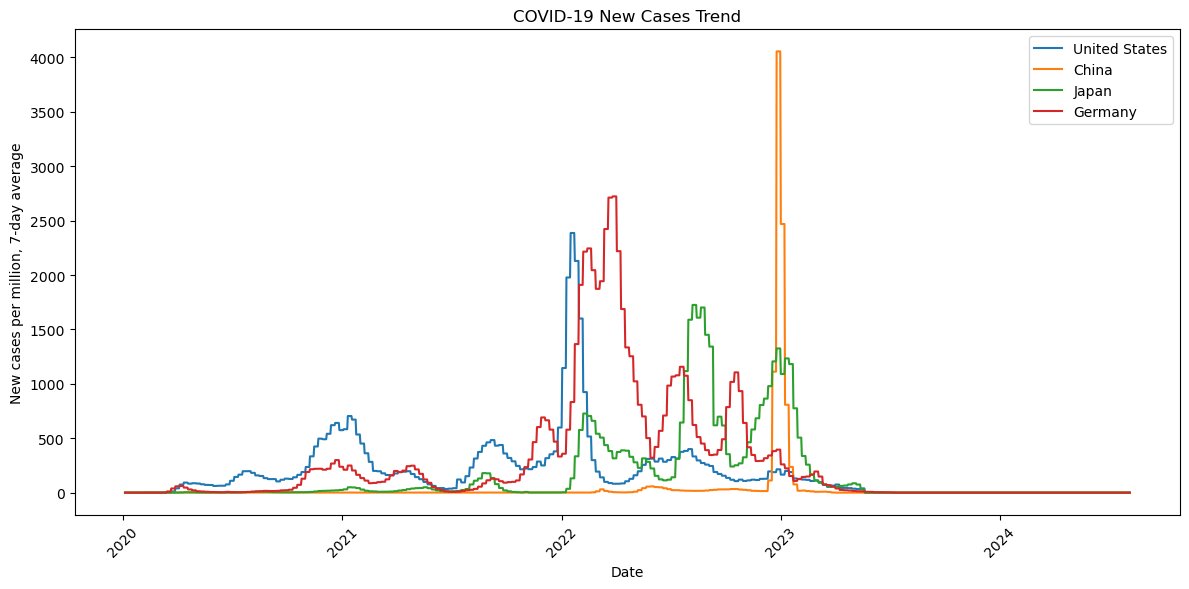

In [100]:
plt.figure(figsize=(12, 6))

for country in countries:
    temp = df_clean[df_clean["location"] == country]
    plt.plot(temp["date"], temp["new_cases_7day_avg"], label=country)

plt.xlabel("Date")
plt.ylabel("New cases per million, 7-day average")
plt.title("COVID-19 New Cases Trend")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Figure 2 New deaths trend

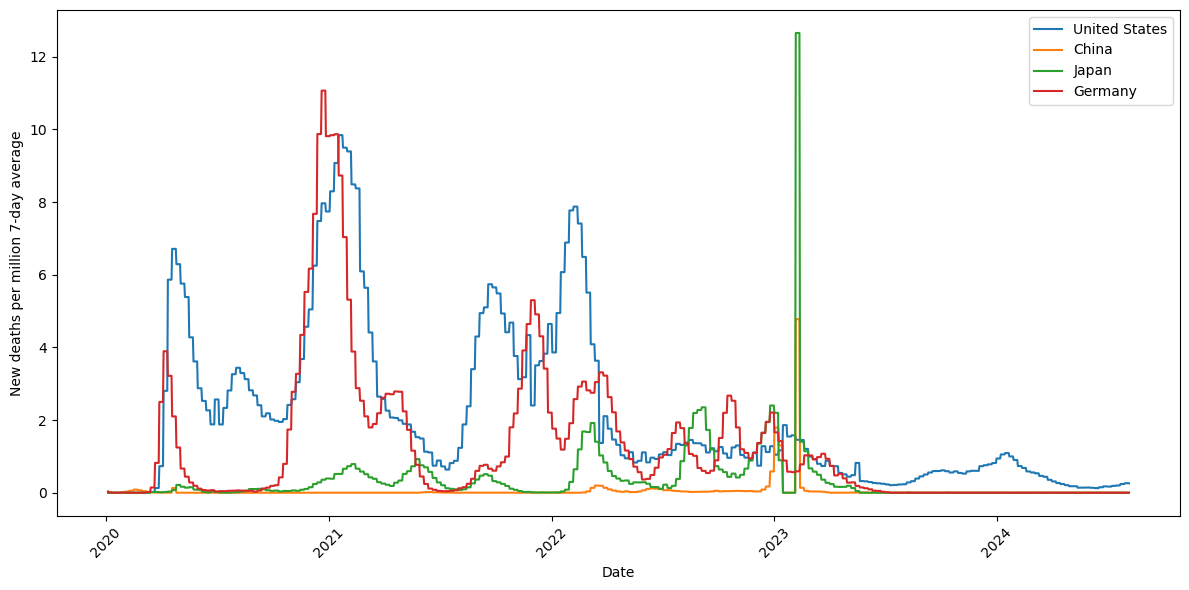

In [102]:
plt.figure(figsize = (12,6))

for country in countries:
    temp = df_clean[df_clean["location"] == country]
    plt.plot(temp["date"],temp["new_deaths_7day_avg"],label = country)

plt.xlabel("Date")
plt.ylabel("New deaths per million 7-day average")
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


## Figure 3 people vacinnated trend

In [104]:
df_clean["vaccinated_percentage"] = df_clean["people_vaccinated"] / df_clean["population"] * 1_000_000

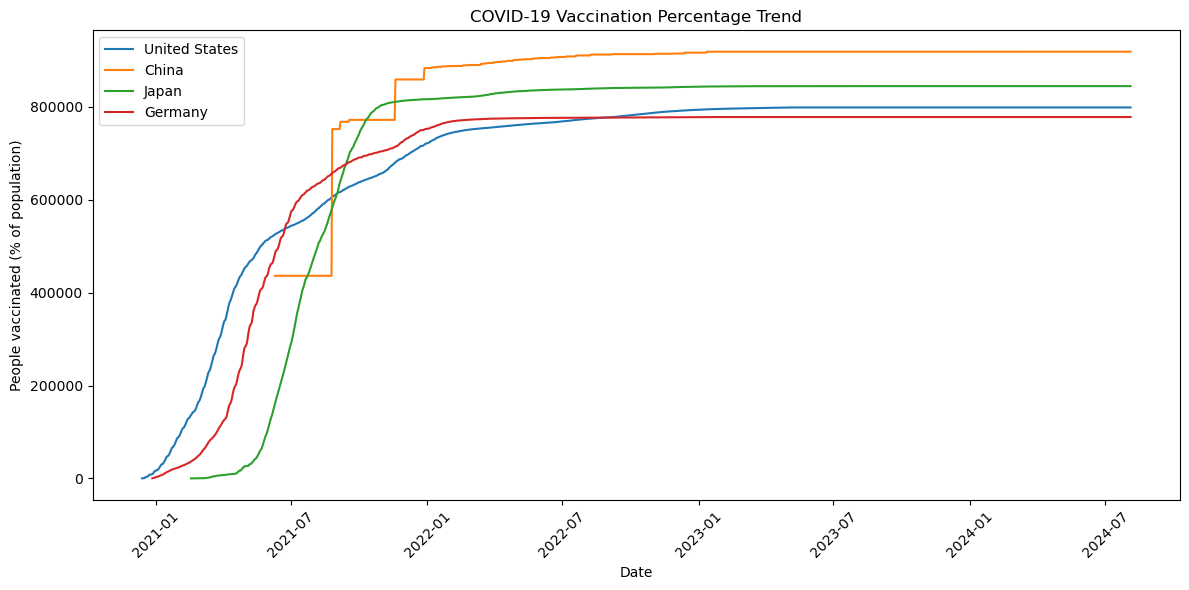

In [105]:
plt.figure(figsize=(12, 6))

for country in countries:
    temp = df_clean[df_clean["location"] == country]
    plt.plot(temp["date"], temp["vaccinated_percentage"], label=country)

plt.xlabel("Date")
plt.ylabel("People vaccinated (% of population)")
plt.title("COVID-19 Vaccination Percentage Trend")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Initial Observation


1. The United States, Germany, and Japan all show several major waves in new cases per million, but the timing and magnitude of these waves differ across countries.

2. The new deaths trend generally follows the new cases trend, but death peaks often appear smoother and may lag behind case peaks.

3. Vaccination rollout curves show a broadly similar pattern across countries: rapid early growth followed by a gradual slowdown and plateau. The main differences are in the timing, slope, and final vaccination percentage. China appears to have several more visible step-like increases.

4. Comparing cases, deaths, and vaccinations using per-million or percentage-based measures is necessary for fair cross-country comparison because the countries have very different population sizes.

5. lthough several countries experienced large Omicron-era infection waves, the corresponding death waves were relatively smaller compared to earlier pandemic stages, potentially reflecting vaccination effects and reduced severity.

In [107]:
df_clean.to_csv("../data/clean_data_4countries.csv", index = False)